# Comprehensive Heart Rate Variability (HRV) Analysis

This notebook provides a complete, comprehensive analysis of HRV using the best methods available in Python.

## Overview

This analysis includes:
- **Time Domain Metrics**: SDNN, RMSSD, pNN50, etc.
- **Frequency Domain Metrics**: VLF, LF, HF powers, LF/HF ratio
- **Nonlinear Metrics**: Poincaré plot, DFA, entropy measures
- **Autonomic Nervous System Analysis**: Parasympathetic and sympathetic indices
- **Advanced Statistical Measures**: Confidence intervals, quality assessment

## Data Source

This notebook is designed to work with RR interval data from **Polar H10** heart rate monitors. The Polar H10 provides high-quality RR interval measurements suitable for comprehensive HRV analysis.

## Requirements

The following Python packages are required:
- `numpy` - Numerical computations
- `pandas` - Data manipulation
- `scipy` - Scientific computing and signal processing
- `matplotlib` - Plotting
- `seaborn` - Statistical visualization
- `hrvanalysis` - HRV analysis library (optional, for additional metrics)

## Data Format

Input data can be provided in multiple formats:

1. **RR Intervals Text File (Polar H10)**: A text file with one RR interval (in milliseconds) per line
   - Example: `2025-11-06 00-50-07.txt`
   - The notebook will automatically load and process these RR intervals
   - File naming convention: `YYYY-MM-DD HH-MM-SS.txt` (date and time of recording)

2. **CSV File with Heart Rate**: A pandas DataFrame with:
   - Heart rate column: `heart_rate [bpm]` or similar
   - Optional grouping columns: `subject`, `date`, `condition`, etc.
   - Optional time column: `timestamp` or `time [s/1000]`

3. **CSV File with RR Intervals**: A pandas DataFrame with:
   - RR intervals column: `rr_intervals_ms` (in milliseconds)
   - Optional grouping columns: `subject`, `date`, `condition`, etc.


In [13]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal, stats
from scipy.interpolate import interp1d
from typing import Dict, Any, Optional, Tuple, List
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Try to import hrvanalysis library (optional)
try:
    from hrvanalysis import (
        get_time_domain_features,
        get_frequency_domain_features,
        get_poincare_plot_features,
    )
    HAS_HRVANALYSIS = True
    print("✅ hrvanalysis library available")
except ImportError:
    HAS_HRVANALYSIS = False
    print("⚠️ hrvanalysis library not available - using custom implementations")

print("Libraries imported successfully!")


✅ hrvanalysis library available
Libraries imported successfully!


## 1. Data Loading and Preparation

Load your data from CSV files, database, or create sample data for testing.


In [14]:
# =============================================================================
# DATA LOADING
# =============================================================================

def load_rr_intervals_from_txt(file_path: str) -> np.ndarray:
    """
    Load RR intervals from a text file with one value per line (in milliseconds).
    
    Args:
        file_path: Path to the text file containing RR intervals
    
    Returns:
        Array of RR intervals in milliseconds
    """
    try:
        with open(file_path, 'r') as f:
            lines = f.readlines()
        
        rr_intervals = []
        for line in lines:
            line = line.strip()
            if line:  # Skip empty lines
                try:
                    rr_value = float(line)
                    # Filter physiologically plausible values (300-2000 ms)
                    if 300 <= rr_value <= 2000:
                        rr_intervals.append(rr_value)
                except ValueError:
                    continue  # Skip non-numeric lines
        
        rr_array = np.array(rr_intervals)
        print(f"✅ Loaded {len(rr_array):,} RR intervals from {file_path}")
        print(f"   RR interval range: {rr_array.min():.1f} - {rr_array.max():.1f} ms")
        print(f"   Mean RR: {rr_array.mean():.1f} ms ({60000/rr_array.mean():.1f} bpm)")
        return rr_array
        
    except FileNotFoundError:
        print(f"❌ File not found: {file_path}")
        return np.array([])
    except Exception as e:
        print(f"❌ Error loading RR intervals: {e}")
        return np.array([])

def load_data_from_csv(file_path: str) -> pd.DataFrame:
    """Load data from CSV file."""
    try:
        df = pd.read_csv(file_path)
        print(f"✅ Loaded {len(df):,} rows from {file_path}")
        return df
    except Exception as e:
        print(f"❌ Error loading data: {e}")
        return None

def load_multiple_csvs(file_paths: Dict[str, str]) -> pd.DataFrame:
    """Load and combine multiple CSV files."""
    dfs = {}
    for name, path in file_paths.items():
        try:
            dfs[name] = pd.read_csv(path)
            dfs[name]['source'] = name
            print(f"✅ Loaded {name}: {len(dfs[name]):,} rows")
        except Exception as e:
            print(f"❌ Error loading {name}: {e}")
    
    if dfs:
        df_combined = pd.concat(dfs.values(), ignore_index=True)
        print(f"✅ Combined dataset: {len(df_combined):,} rows")
        return df_combined
    return None

# =============================================================================
# LOAD RR INTERVALS FROM TEXT FILE (POLAR H10)
# =============================================================================

# Load RR intervals from the specified file
# File is in the root directory, notebook is in scripts/ subdirectory
import os
# Use absolute path to ensure correct file location
rr_file_path = r'C:\Users\User\OneDrive\FAC\Research\Python Scripts\HRV\2025-11-06 00-50-07.txt'
# Alternative: relative path (go up one level from scripts/ to root)
# rr_file_path = os.path.join('..', '2025-11-06 00-50-07.txt')

rr_intervals = load_rr_intervals_from_txt(rr_file_path)

if len(rr_intervals) > 0:
    # Extract date and time from filename (format: YYYY-MM-DD HH-MM-SS.txt)
    import os
    from datetime import datetime
    
    filename = os.path.basename(rr_file_path)
    # Remove .txt extension and parse date/time
    date_time_str = filename.replace('.txt', '')
    try:
        recording_datetime = datetime.strptime(date_time_str, '%Y-%m-%d %H-%M-%S')
        recording_date = recording_datetime.date()
    except ValueError:
        # Fallback if filename format doesn't match
        recording_datetime = datetime(2025, 11, 6, 0, 50, 7)
        recording_date = recording_datetime.date()
        print(f"⚠️ Could not parse date from filename, using default: {recording_date}")
    
    # Convert RR intervals to heart rate for compatibility with existing functions
    heart_rate_bpm = 60000.0 / rr_intervals
    
    # Create timestamps based on cumulative RR intervals
    rr_cumulative = np.cumsum(rr_intervals) / 1000.0  # Convert to seconds
    timestamps = [recording_datetime + pd.Timedelta(seconds=rr_cumulative[i]) 
                  for i in range(len(rr_intervals))]
    
    # Create DataFrame with RR intervals and heart rate
    df = pd.DataFrame({
        'rr_intervals_ms': rr_intervals,
        'heart_rate [bpm]': heart_rate_bpm,
        'beat_index': np.arange(len(rr_intervals)),
        'date': [recording_date] * len(rr_intervals),
        'timestamp': timestamps
    })
    
    print(f"\n✅ Created DataFrame with {len(df):,} beats")
    print(f"   Recording date: {recording_date}")
    print(f"   Recording start time: {recording_datetime.strftime('%H:%M:%S')}")
    print(f"   Recording duration: {rr_intervals.sum() / 1000 / 60:.2f} minutes")
else:
    print("\n⚠️ No RR intervals loaded. Creating sample data for demonstration...")
    np.random.seed(42)
    n_samples = 1000
    base_hr = 70
    noise = np.random.normal(0, 5, n_samples)
    trend = np.sin(np.linspace(0, 4*np.pi, n_samples)) * 10
    
    heart_rate = base_hr + noise + trend
    heart_rate = np.clip(heart_rate, 50, 120)
    
    df = pd.DataFrame({
        'heart_rate [bpm]': heart_rate,
        'subject': ['SampleSubject'] * n_samples,
        'date': pd.date_range('2023-01-01', periods=n_samples, freq='1s').date,
        'timestamp': pd.date_range('2023-01-01', periods=n_samples, freq='1s')
    })
    print(f"✅ Created sample dataset with {len(df):,} rows")

# Display data info
print("\nData Info:")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()


✅ Loaded 13,859 RR intervals from C:\Users\User\OneDrive\FAC\Research\Python Scripts\HRV\2025-11-06 00-50-07.txt
   RR interval range: 336.0 - 1728.0 ms
   Mean RR: 941.0 ms (63.8 bpm)

✅ Created DataFrame with 13,859 beats
   Recording date: 2025-11-06
   Recording start time: 00:50:07
   Recording duration: 217.36 minutes

Data Info:
Shape: (13859, 5)
Columns: ['rr_intervals_ms', 'heart_rate [bpm]', 'beat_index', 'date', 'timestamp']

First few rows:


,rr_intervals_ms,heart_rate [bpm],beat_index,date,timestamp
0,942.0,63.694268,0,2025-11-06,2025-11-06 00:50:07.942
1,949.0,63.224447,1,2025-11-06,2025-11-06 00:50:08.891
2,951.0,63.091483,2,2025-11-06,2025-11-06 00:50:09.842
3,933.0,64.308682,3,2025-11-06,2025-11-06 00:50:10.775
4,935.0,64.171123,4,2025-11-06,2025-11-06 00:50:11.710


## 2. Core HRV Analysis Functions

These functions implement the best HRV analysis methods available in Python.


In [15]:
# =============================================================================
# CORE HRV ANALYSIS FUNCTIONS
# =============================================================================

def rr_from_hr(hr_series: pd.Series, min_rr: float = 300, max_rr: float = 2000) -> np.ndarray:
    """
    Convert heart rate (bpm) to RR intervals (ms).
    
    Args:
        hr_series: Heart rate data in BPM
        min_rr: Minimum physiologically plausible RR interval (ms)
        max_rr: Maximum physiologically plausible RR interval (ms)
    
    Returns:
        Array of RR intervals in milliseconds
    """
    try:
        hr_clean = pd.to_numeric(hr_series, errors='coerce').dropna()
        
        if len(hr_clean) == 0:
            return np.array([])
        
        # Convert to RR intervals: RR(ms) = 60000 / HR(bpm)
        rr_ms = 60000.0 / hr_clean
        rr_ms = rr_ms.replace([np.inf, -np.inf], np.nan).dropna()
        
        # Filter physiologically plausible values
        rr_ms = rr_ms[(rr_ms >= min_rr) & (rr_ms <= max_rr)]
        
        return rr_ms.values
        
    except Exception as e:
        print(f"❌ Error converting HR to RR: {e}")
        return np.array([])

def compute_time_domain_metrics(rr_intervals: np.ndarray) -> Dict[str, float]:
    """
    Compute time domain HRV metrics.
    
    Returns:
        Dictionary of time domain metrics
    """
    if len(rr_intervals) == 0:
        return {}
    
    metrics = {}
    
    # Basic statistics
    metrics['mean_nni'] = np.mean(rr_intervals)
    metrics['sdnn'] = np.std(rr_intervals, ddof=1)
    metrics['median_nni'] = np.median(rr_intervals)
    metrics['mad_nni'] = np.median(np.abs(rr_intervals - metrics['median_nni']))
    metrics['cvnn'] = (metrics['sdnn'] / metrics['mean_nni']) * 100 if metrics['mean_nni'] > 0 else 0
    
    # Heart rate statistics
    hr_values = 60000 / rr_intervals
    metrics['mean_hr'] = np.mean(hr_values)
    metrics['std_hr'] = np.std(hr_values, ddof=1)
    metrics['min_hr'] = np.min(hr_values)
    metrics['max_hr'] = np.max(hr_values)
    
    # Successive difference measures
    if len(rr_intervals) > 1:
        rr_diff = np.diff(rr_intervals)
        metrics['rmssd'] = np.sqrt(np.mean(rr_diff ** 2))
        metrics['sdsd'] = np.std(rr_diff, ddof=1)
        metrics['cvsd'] = (metrics['sdsd'] / np.mean(np.abs(rr_diff))) * 100 if np.mean(np.abs(rr_diff)) > 0 else 0
        
        # NN50 and pNN50
        nn50 = np.sum(np.abs(rr_diff) > 50)
        metrics['nn50'] = int(nn50)
        metrics['pnn50'] = (nn50 / len(rr_diff)) * 100
        
        # NN20 and pNN20
        nn20 = np.sum(np.abs(rr_diff) > 20)
        metrics['nn20'] = int(nn20)
        metrics['pnn20'] = (nn20 / len(rr_diff)) * 100
    else:
        metrics['rmssd'] = 0
        metrics['sdsd'] = 0
        metrics['cvsd'] = 0
        metrics['nn50'] = 0
        metrics['pnn50'] = 0
        metrics['nn20'] = 0
        metrics['pnn20'] = 0
    
    return metrics

print("✅ Core HRV functions defined")


✅ Core HRV functions defined


In [16]:
def compute_frequency_domain_metrics(rr_intervals: np.ndarray, 
                                     method: str = 'welch',
                                     sampling_rate: float = 4.0) -> Dict[str, float]:
    """
    Compute frequency domain HRV metrics using power spectral density.
    
    Args:
        rr_intervals: RR intervals in milliseconds
        method: PSD estimation method ('welch' or 'periodogram')
        sampling_rate: Sampling rate for interpolation (Hz)
    
    Returns:
        Dictionary of frequency domain metrics
    """
    if len(rr_intervals) < 50:
        return {}
    
    try:
        # Create time series for interpolation
        rr_seconds = rr_intervals / 1000.0
        r_peak_times = np.concatenate([[0], np.cumsum(rr_seconds)])
        rr_timestamps = (r_peak_times[:-1] + r_peak_times[1:]) / 2.0
        
        # Create regular time grid
        total_duration = r_peak_times[-1]
        if total_duration <= 0:
            return {}
        
        time_regular = np.arange(0, total_duration, 1/sampling_rate)
        
        if len(time_regular) < 10:
            return {}
        
        # Interpolate RR intervals
        interp_kind = 'cubic' if len(rr_intervals) >= 4 else 'linear'
        f_interp = interp1d(rr_timestamps, rr_intervals, 
                          kind=interp_kind,
                          bounds_error=False, 
                          fill_value='extrapolate')
        rr_interpolated = f_interp(time_regular)
        
        # Detrend
        rr_detrended = signal.detrend(rr_interpolated)
        
        # Compute power spectral density
        if method == 'welch':
            freqs, psd = signal.welch(rr_detrended, fs=sampling_rate, 
                                    nperseg=min(len(rr_detrended)//4, 256),
                                    window='hann')
        else:
            freqs, psd = signal.periodogram(rr_detrended, fs=sampling_rate, window='hann')
        
        # Define frequency bands (Hz)
        vlf_band = (0.0033, 0.04)
        lf_band = (0.04, 0.15)
        hf_band = (0.15, 0.4)
        
        # Calculate power in each band
        vlf_mask = (freqs >= vlf_band[0]) & (freqs < vlf_band[1])
        lf_mask = (freqs >= lf_band[0]) & (freqs < lf_band[1])
        hf_mask = (freqs >= hf_band[0]) & (freqs < hf_band[1])
        
        vlf_power = np.trapz(psd[vlf_mask], freqs[vlf_mask]) if np.any(vlf_mask) else 0
        lf_power = np.trapz(psd[lf_mask], freqs[lf_mask]) if np.any(lf_mask) else 0
        hf_power = np.trapz(psd[hf_mask], freqs[hf_mask]) if np.any(hf_mask) else 0
        total_power = vlf_power + lf_power + hf_power
        
        # Normalized units
        lf_nu = (lf_power / (lf_power + hf_power)) * 100 if (lf_power + hf_power) > 0 else 0
        hf_nu = (hf_power / (lf_power + hf_power)) * 100 if (lf_power + hf_power) > 0 else 0
        lf_hf_ratio = lf_power / hf_power if hf_power > 0 else 0
        
        # Percentages
        vlf_percent = (vlf_power / total_power) * 100 if total_power > 0 else 0
        lf_percent = (lf_power / total_power) * 100 if total_power > 0 else 0
        hf_percent = (hf_power / total_power) * 100 if total_power > 0 else 0
        
        # Peak frequencies
        vlf_peak = freqs[vlf_mask][np.argmax(psd[vlf_mask])] if np.any(vlf_mask) and vlf_power > 0 else 0
        lf_peak = freqs[lf_mask][np.argmax(psd[lf_mask])] if np.any(lf_mask) and lf_power > 0 else 0
        hf_peak = freqs[hf_mask][np.argmax(psd[hf_mask])] if np.any(hf_mask) and hf_power > 0 else 0
        
        return {
            'vlf_power': vlf_power,
            'lf_power': lf_power,
            'hf_power': hf_power,
            'total_power': total_power,
            'lf_nu': lf_nu,
            'hf_nu': hf_nu,
            'lf_hf_ratio': lf_hf_ratio,
            'vlf_percent': vlf_percent,
            'lf_percent': lf_percent,
            'hf_percent': hf_percent,
            'vlf_peak': vlf_peak,
            'lf_peak': lf_peak,
            'hf_peak': hf_peak,
            'method': method,
            'sampling_rate': sampling_rate
        }
        
    except Exception as e:
        print(f"⚠️ Frequency domain analysis failed: {e}")
        return {}

print("✅ Frequency domain functions defined")


✅ Frequency domain functions defined


In [17]:
def compute_poincare_metrics(rr_intervals: np.ndarray) -> Dict[str, float]:
    """
    Compute Poincaré plot metrics.
    
    Returns:
        Dictionary of Poincaré plot metrics
    """
    if len(rr_intervals) < 2:
        return {}
    
    try:
        rr1 = rr_intervals[:-1]
        rr2 = rr_intervals[1:]
        
        # SD1 and SD2
        diff = rr2 - rr1
        sum_rr = rr2 + rr1
        
        sd1 = np.std(diff) / np.sqrt(2)
        sd2 = np.std(sum_rr) / np.sqrt(2)
        sd1_sd2_ratio = sd2 / sd1 if sd1 > 0 else 0
        
        # Ellipse area
        ellipse_area = np.pi * sd1 * sd2 if sd1 > 0 and sd2 > 0 else 0
        
        return {
            'sd1': sd1,
            'sd2': sd2,
            'sd1_sd2_ratio': sd1_sd2_ratio,
            'ellipse_area': ellipse_area
        }
        
    except Exception as e:
        print(f"⚠️ Poincaré analysis failed: {e}")
        return {}

def compute_dfa_metrics(rr_intervals: np.ndarray) -> Dict[str, float]:
    """
    Compute Detrended Fluctuation Analysis (DFA) metrics.
    
    Returns:
        Dictionary with DFA alpha1 and alpha2
    """
    if len(rr_intervals) < 100:
        return {'dfa_alpha1': 0, 'dfa_alpha2': 0}
    
    try:
        # Create cumulative sum
        y = np.cumsum(rr_intervals - np.mean(rr_intervals))
        
        # Define scales
        scales_short = np.arange(4, min(17, len(rr_intervals)//4))
        scales_long = np.arange(16, min(65, len(rr_intervals)//4))
        
        def compute_fluctuation(scales):
            fluctuations = []
            for scale in scales:
                segments = len(y) // scale
                if segments < 4:
                    continue
                
                local_fluctuations = []
                for i in range(segments):
                    start = i * scale
                    end = start + scale
                    segment = y[start:end]
                    
                    # Detrend
                    x_segment = np.arange(len(segment))
                    coeffs = np.polyfit(x_segment, segment, 1)
                    trend = np.polyval(coeffs, x_segment)
                    detrended = segment - trend
                    
                    local_fluctuations.append(np.sqrt(np.mean(detrended**2)))
                
                if local_fluctuations:
                    fluctuations.append(np.mean(local_fluctuations))
            
            return fluctuations
        
        fluc_short = compute_fluctuation(scales_short)
        fluc_long = compute_fluctuation(scales_long)
        
        # Calculate scaling exponents
        alpha1 = alpha2 = 0
        
        if len(fluc_short) > 2 and np.all(np.array(fluc_short) > 0):
            log_scales = np.log10(scales_short[:len(fluc_short)])
            log_fluc = np.log10(fluc_short)
            alpha1, _ = np.polyfit(log_scales, log_fluc, 1)
        
        if len(fluc_long) > 2 and np.all(np.array(fluc_long) > 0):
            log_scales = np.log10(scales_long[:len(fluc_long)])
            log_fluc = np.log10(fluc_long)
            alpha2, _ = np.polyfit(log_scales, log_fluc, 1)
        
        return {
            'dfa_alpha1': float(alpha1),
            'dfa_alpha2': float(alpha2)
        }
        
    except Exception as e:
        print(f"⚠️ DFA computation failed: {e}")
        return {'dfa_alpha1': 0, 'dfa_alpha2': 0}

print("✅ Nonlinear metrics functions defined")


✅ Nonlinear metrics functions defined


In [18]:
def compute_comprehensive_hrv(rr_intervals: np.ndarray, 
                              use_hrvanalysis: bool = False) -> Dict[str, Any]:
    """
    Compute comprehensive HRV metrics using all available methods.
    
    Args:
        rr_intervals: RR intervals in milliseconds
        use_hrvanalysis: Whether to use hrvanalysis library if available
    
    Returns:
        Dictionary containing all HRV metrics
    """
    results = {
        'n_intervals': len(rr_intervals),
        'recording_duration_minutes': np.sum(rr_intervals) / (1000 * 60)
    }
    
    if len(rr_intervals) < 10:
        return results
    
    # Time domain metrics
    time_metrics = compute_time_domain_metrics(rr_intervals)
    results.update(time_metrics)
    
    # Frequency domain metrics
    freq_metrics = compute_frequency_domain_metrics(rr_intervals)
    results.update(freq_metrics)
    
    # Poincaré metrics
    poincare_metrics = compute_poincare_metrics(rr_intervals)
    results.update(poincare_metrics)
    
    # DFA metrics
    dfa_metrics = compute_dfa_metrics(rr_intervals)
    results.update(dfa_metrics)
    
    # Use hrvanalysis library if available and requested
    if use_hrvanalysis and HAS_HRVANALYSIS and len(rr_intervals) >= 50:
        try:
            hrv_time = get_time_domain_features(rr_intervals)
            hrv_freq = get_frequency_domain_features(rr_intervals)
            hrv_poincare = get_poincare_plot_features(rr_intervals)
            
            # Add prefix to avoid conflicts
            results.update({f'hrvanalysis_{k}': v for k, v in hrv_time.items()})
            results.update({f'hrvanalysis_{k}': v for k, v in hrv_freq.items()})
            results.update({f'hrvanalysis_{k}': v for k, v in hrv_poincare.items()})
        except Exception as e:
            print(f"⚠️ hrvanalysis library computation failed: {e}")
    
    # Compute ANS indices
    if 'hf_power' in results and 'rmssd' in results:
        # Parasympathetic index (higher HF, RMSSD, pNN50, SD1 = higher parasympathetic)
        parasympathetic_components = [
            results.get('hf_nu', 0) / 100,
            min(1.0, results.get('rmssd', 0) / 100),
            min(1.0, results.get('pnn50', 0) / 50),
            min(1.0, results.get('sd1', 0) / 50)
        ]
        results['parasympathetic_index'] = np.mean([c for c in parasympathetic_components if c > 0])
        
        # Sympathetic index (higher LF/HF ratio = higher sympathetic)
        lf_hf_ratio = results.get('lf_hf_ratio', 0)
        results['sympathetic_index'] = min(1.0, lf_hf_ratio / 5.0)
        
        # ANS balance
        results['ans_balance'] = results['parasympathetic_index'] - results['sympathetic_index']
    
    return results

print("✅ Comprehensive HRV analysis function defined")


✅ Comprehensive HRV analysis function defined


## 3. Perform HRV Analysis

Analyze HRV for your data. You can analyze the entire dataset or group by subject, condition, etc.


In [19]:
# =============================================================================
# PERFORM HRV ANALYSIS
# =============================================================================

def analyze_hrv_dataframe(df: pd.DataFrame, 
                         hr_column: str = 'heart_rate [bpm]',
                         rr_column: str = 'rr_intervals_ms',
                         group_by: List[str] = None) -> pd.DataFrame:
    """
    Analyze HRV for a DataFrame, optionally grouped by columns.
    
    Args:
        df: Input DataFrame
        hr_column: Name of heart rate column (used if RR intervals not available)
        rr_column: Name of RR intervals column (in milliseconds)
        group_by: List of column names to group by (e.g., ['subject', 'date'])
    
    Returns:
        DataFrame with HRV metrics
    """
    # Check if RR intervals are directly available
    has_rr_intervals = rr_column in df.columns
    
    if not has_rr_intervals:
        if hr_column not in df.columns:
            print(f"❌ Neither '{rr_column}' nor '{hr_column}' found in data")
            print(f"Available columns: {list(df.columns)}")
            return pd.DataFrame()
        print(f"Using heart rate column '{hr_column}' to compute RR intervals")
    else:
        print(f"Using RR intervals directly from column '{rr_column}'")
    
    results = []
    
    def get_rr_intervals(data_subset: pd.DataFrame) -> np.ndarray:
        """Get RR intervals from either RR column or HR column."""
        if has_rr_intervals:
            rr = data_subset[rr_column].dropna().values
            # Filter physiologically plausible values
            rr = rr[(rr >= 300) & (rr <= 2000)]
            return rr
        else:
            return rr_from_hr(data_subset[hr_column])
    
    if group_by is None:
        # Analyze entire dataset
        print("Analyzing entire dataset...")
        rr_intervals = get_rr_intervals(df)
        if len(rr_intervals) >= 10:
            metrics = compute_comprehensive_hrv(rr_intervals, use_hrvanalysis=HAS_HRVANALYSIS)
            results.append(metrics)
        else:
            print(f"⚠️ Insufficient data: {len(rr_intervals)} RR intervals")
    else:
        # Group by specified columns
        available_groups = [col for col in group_by if col in df.columns]
        if not available_groups:
            print(f"⚠️ None of the grouping columns found. Analyzing entire dataset...")
            rr_intervals = get_rr_intervals(df)
            if len(rr_intervals) >= 10:
                metrics = compute_comprehensive_hrv(rr_intervals, use_hrvanalysis=HAS_HRVANALYSIS)
                results.append(metrics)
        else:
            print(f"Analyzing by: {', '.join(available_groups)}")
            for keys, group_df in df.groupby(available_groups):
                if isinstance(keys, tuple):
                    group_name = ' | '.join([f"{col}={val}" for col, val in zip(available_groups, keys)])
                else:
                    group_name = f"{available_groups[0]}={keys}"
                
                print(f"  Processing {group_name}...")
                rr_intervals = get_rr_intervals(group_df)
                
                if len(rr_intervals) >= 10:
                    metrics = compute_comprehensive_hrv(rr_intervals, use_hrvanalysis=HAS_HRVANALYSIS)
                    # Add grouping information
                    if isinstance(keys, tuple):
                        for col, val in zip(available_groups, keys):
                            metrics[col] = val
                    else:
                        metrics[available_groups[0]] = keys
                    results.append(metrics)
                else:
                    print(f"    ⚠️ Insufficient data: {len(rr_intervals)} RR intervals")
    
    if results:
        results_df = pd.DataFrame(results)
        print(f"\n✅ Analysis complete: {len(results_df)} segments analyzed")
        return results_df
    else:
        print("❌ No results generated")
        return pd.DataFrame()

# Perform analysis
# Modify group_by parameter based on your data structure
group_by_columns = []
if 'subject' in df.columns:
    group_by_columns.append('subject')
if 'date' in df.columns:
    group_by_columns.append('date')

hrv_results = analyze_hrv_dataframe(df, 
                                  hr_column='heart_rate [bpm]',
                                  group_by=group_by_columns if group_by_columns else None)

# Display results
if not hrv_results.empty:
    print("\nHRV Analysis Results:")
    print("=" * 80)
    display(hrv_results)
else:
    print("No results to display")


Using RR intervals directly from column 'rr_intervals_ms'
Analyzing by: date
  Processing date=2025-11-06...

✅ Analysis complete: 1 segments analyzed

HRV Analysis Results:


,n_intervals,recording_duration_minutes,mean_nni,sdnn,median_nni,mad_nni,cvnn,mean_hr,std_hr,min_hr,...,hrvanalysis_hfnu,hrvanalysis_total_power,hrvanalysis_vlf,hrvanalysis_sd1,hrvanalysis_sd2,hrvanalysis_ratio_sd2_sd1,parasympathetic_index,sympathetic_index,ans_balance,date
0,13859,217.361817,941.028141,95.614992,954.0,64.0,10.160694,64.470772,7.089805,34.722222,...,17.483905,1870.006915,986.02037,19.535336,133.801435,6.849201,0.235175,0.648211,-0.413036,2025-11-06


In [26]:
# =============================================================================
# VISUALIZATION FUNCTIONS
# =============================================================================

def plot_rr_timeseries(rr_intervals: np.ndarray, title: str = "RR Interval Time Series"):
    """Plot RR interval time series."""
    if len(rr_intervals) == 0:
        print("No data to plot")
        return
    
    plt.figure(figsize=(14, 4))
    plt.plot(np.arange(len(rr_intervals)), rr_intervals / 1000.0, linewidth=0.7)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Beat index", fontsize=12)
    plt.ylabel("RR interval (s)", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_psd(rr_intervals: np.ndarray, title: str = "Power Spectral Density", 
             sampling_rate: float = 4.0):
    """Plot power spectral density."""
    if len(rr_intervals) < 50:
        print("Insufficient data for PSD analysis")
        return
    
    try:
        # Interpolate RR intervals
        rr_seconds = rr_intervals / 1000.0
        r_peak_times = np.concatenate([[0], np.cumsum(rr_seconds)])
        rr_timestamps = (r_peak_times[:-1] + r_peak_times[1:]) / 2.0
        
        total_duration = r_peak_times[-1]
        time_regular = np.arange(0, total_duration, 1/sampling_rate)
        
        f_interp = interp1d(rr_timestamps, rr_intervals, 
                          kind='linear', bounds_error=False, fill_value='extrapolate')
        rr_interpolated = f_interp(time_regular)
        rr_detrended = signal.detrend(rr_interpolated)
        
        # Compute PSD
        freqs, psd = signal.welch(rr_detrended, fs=sampling_rate, 
                                nperseg=min(256, len(rr_detrended)//4))
        
        plt.figure(figsize=(10, 5))
        plt.semilogy(freqs, psd, lw=1.2)
        plt.title(title, fontsize=14, fontweight='bold')
        plt.xlabel("Frequency (Hz)", fontsize=12)
        plt.ylabel("PSD (ms²/Hz)", fontsize=12)
        
        # Add frequency band markers
        plt.axvline(0.04, color='r', linestyle='--', alpha=0.5, label='LF band')
        plt.axvline(0.15, color='r', linestyle='--', alpha=0.5)
        plt.axvline(0.4, color='g', linestyle='--', alpha=0.5, label='HF band')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error plotting PSD: {e}")

def plot_poincare(rr_intervals: np.ndarray, title: str = "Poincaré Plot"):
    """Plot Poincaré plot."""
    if len(rr_intervals) < 2:
        print("Insufficient data for Poincaré plot")
        return
    
    rr1 = rr_intervals[:-1]
    rr2 = rr_intervals[1:]
    
    plt.figure(figsize=(8, 8))
    plt.scatter(rr1, rr2, s=8, alpha=0.6)
    
    # Add identity line
    lims = [min(rr1.min(), rr2.min()), max(rr1.max(), rr2.max())]
    plt.plot(lims, lims, "k--", alpha=0.6, label='Identity line')
    
    # Add SD1 and SD2 ellipses
    sd1 = np.std(rr2 - rr1) / np.sqrt(2)
    sd2 = np.std(rr2 + rr1) / np.sqrt(2)
    mean_rr = np.mean(rr_intervals)
    
    from matplotlib.patches import Ellipse
    ellipse = Ellipse((mean_rr, mean_rr), 2*sd1, 2*sd2, 
                     angle=45, alpha=0.2, color='red', label='SD1/SD2 ellipse')
    plt.gca().add_patch(ellipse)
    
    plt.xlabel("RRₙ (ms)", fontsize=12)
    plt.ylabel("RRₙ₊₁ (ms)", fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("✅ Visualization functions defined")


✅ Visualization functions defined


Generating visualizations...


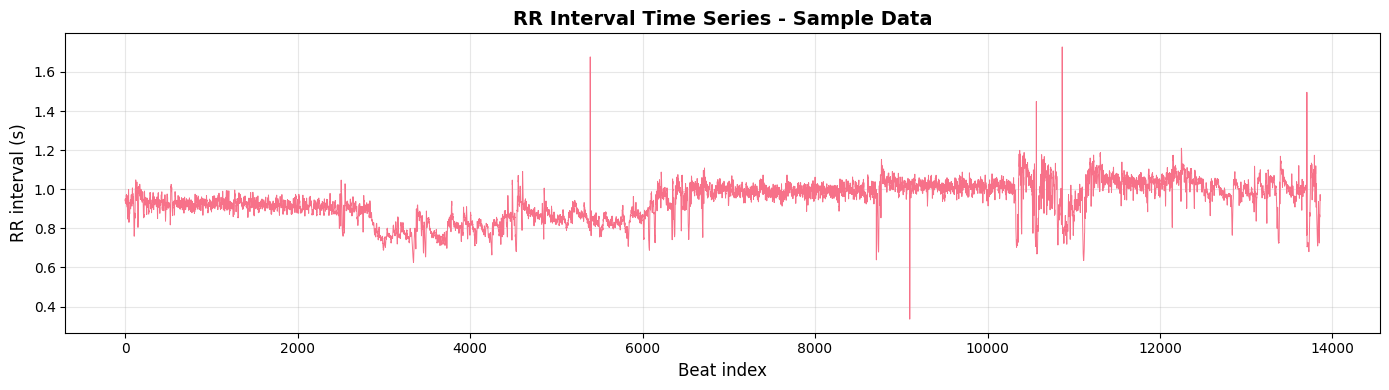

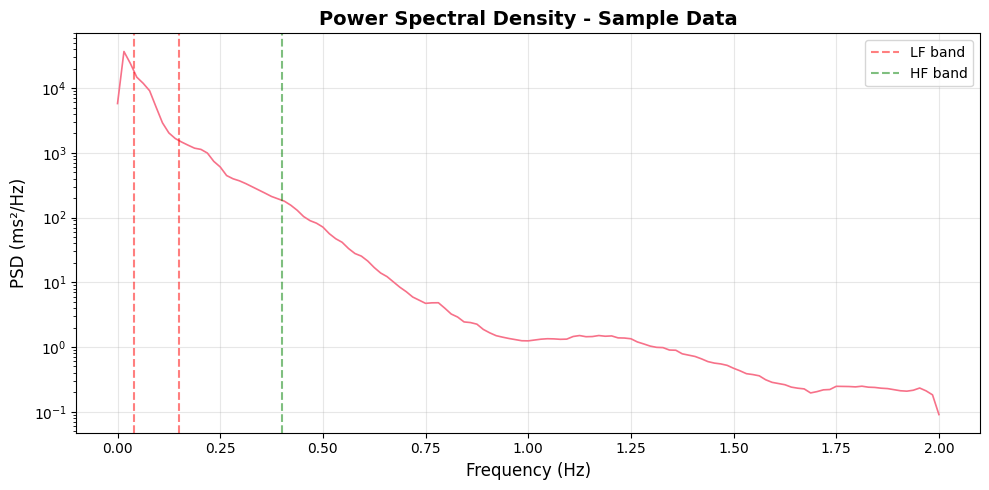

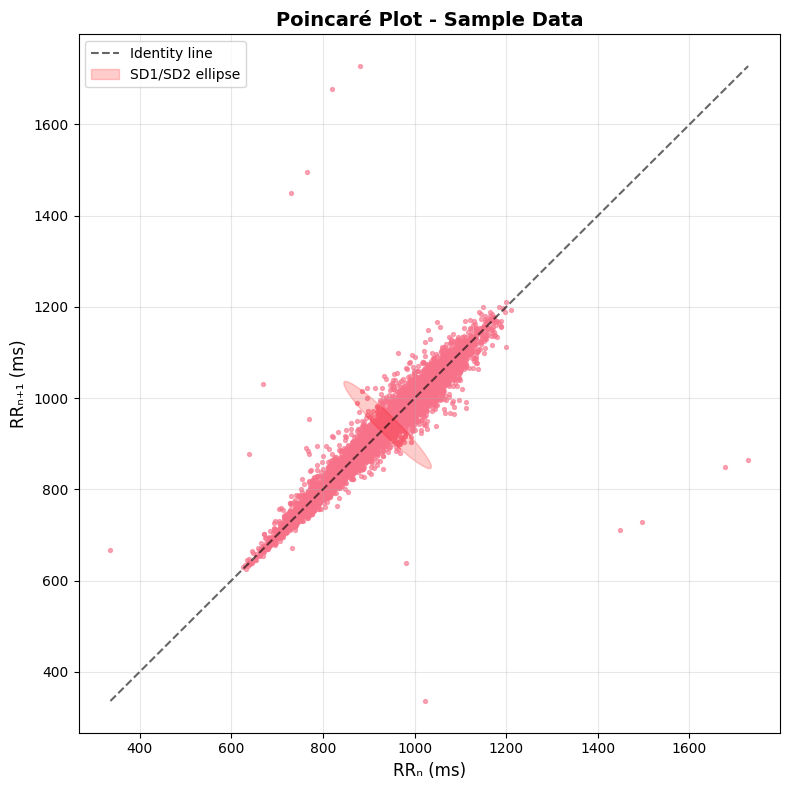

In [27]:
# Generate visualizations for a sample segment
if not hrv_results.empty and 'df' in locals():
    # Get RR intervals for visualization
    # Check if RR intervals are directly available
    if 'rr_intervals_ms' in df.columns:
        # Use RR intervals directly
        if group_by_columns:
            first_group_key = df[group_by_columns[0]].iloc[0] if group_by_columns else None
            if first_group_key is not None:
                sample_df = df[df[group_by_columns[0]] == first_group_key]
            else:
                sample_df = df
        else:
            sample_df = df
        sample_rr = sample_df['rr_intervals_ms'].dropna().values
        sample_rr = sample_rr[(sample_rr >= 300) & (sample_rr <= 2000)]
    else:
        # Convert from heart rate
        if group_by_columns:
            first_group = df.groupby(group_by_columns).first()
            if not first_group.empty:
                sample_rr = rr_from_hr(df[df[group_by_columns[0]] == df[group_by_columns[0]].iloc[0]]['heart_rate [bpm]'])
            else:
                sample_rr = rr_from_hr(df['heart_rate [bpm]'])
        else:
            sample_rr = rr_from_hr(df['heart_rate [bpm]'])
    
    if len(sample_rr) >= 10:
        print("Generating visualizations...")
        plot_rr_timeseries(sample_rr, "RR Interval Time Series - Sample Data")
        
        if len(sample_rr) >= 50:
            plot_psd(sample_rr, "Power Spectral Density - Sample Data")
        
        if len(sample_rr) >= 2:
            plot_poincare(sample_rr, "Poincaré Plot - Sample Data")
    else:
        print("Insufficient data for visualization")


## 5. Summary Statistics and Comparisons

Generate summary statistics and compare HRV metrics across groups.


HRV Metrics Summary


,mean_hr,sdnn,rmssd,pnn50,lf_power,hf_power,lf_hf_ratio,sd1,sd2,parasympathetic_index,sympathetic_index
count,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
mean,64.470772,95.614992,27.62614,1.897821,638.736024,197.076499,3.241056,19.534631,133.801535,0.235175,0.648211
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,64.470772,95.614992,27.62614,1.897821,638.736024,197.076499,3.241056,19.534631,133.801535,0.235175,0.648211
25%,64.470772,95.614992,27.62614,1.897821,638.736024,197.076499,3.241056,19.534631,133.801535,0.235175,0.648211
50%,64.470772,95.614992,27.62614,1.897821,638.736024,197.076499,3.241056,19.534631,133.801535,0.235175,0.648211
75%,64.470772,95.614992,27.62614,1.897821,638.736024,197.076499,3.241056,19.534631,133.801535,0.235175,0.648211
max,64.470772,95.614992,27.62614,1.897821,638.736024,197.076499,3.241056,19.534631,133.801535,0.235175,0.648211




Grouped Summary Statistics


mean_hr                 sdnn               rmssd            \
                 mean std count       mean std count      mean std count   
date                                                                       
2025-11-06  64.470772 NaN     1  95.614992 NaN     1  27.62614 NaN     1   

               pnn50  ...   sd1         sd2           parasympathetic_index  \
                mean  ... count        mean std count                  mean   
date                  ...                                                     
2025-11-06  1.897821  ...     1  133.801535 NaN     1              0.235175   

                     sympathetic_index            
           std count              mean std count  
date                                              
2025-11-06 NaN     1          0.648211 NaN     1  

[1 rows x 33 columns]



Correlation Matrix of Key Metrics


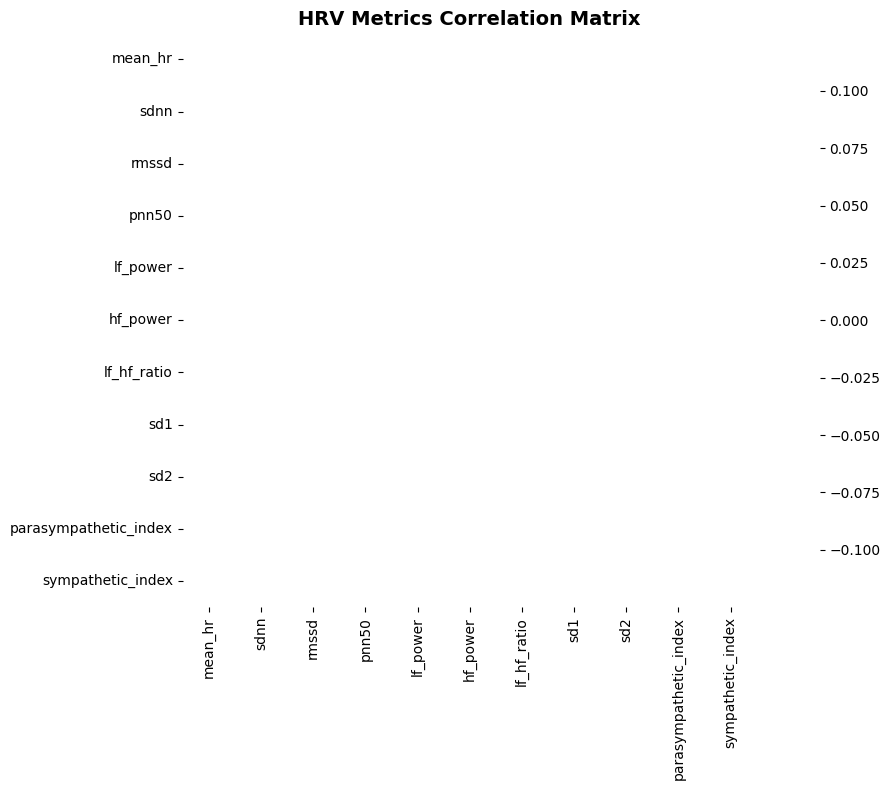

In [28]:
# =============================================================================
# SUMMARY STATISTICS AND COMPARISONS
# =============================================================================

if not hrv_results.empty:
    print("HRV Metrics Summary")
    print("=" * 80)
    
    # Key metrics to display
    key_metrics = ['mean_hr', 'sdnn', 'rmssd', 'pnn50', 'lf_power', 'hf_power', 
                   'lf_hf_ratio', 'sd1', 'sd2', 'parasympathetic_index', 'sympathetic_index']
    
    available_metrics = [m for m in key_metrics if m in hrv_results.columns]
    
    if available_metrics:
        summary = hrv_results[available_metrics].describe()
        display(summary)
        
        # Group comparisons if grouping columns exist
        if group_by_columns:
            group_cols = [col for col in group_by_columns if col in hrv_results.columns]
            if group_cols:
                print(f"\n\nGrouped Summary Statistics")
                print("=" * 80)
                grouped_summary = hrv_results.groupby(group_cols)[available_metrics].agg(['mean', 'std', 'count'])
                display(grouped_summary)
    else:
        print("No key metrics available for summary")
        
    # Correlation matrix of key metrics
    if len(available_metrics) > 1:
        print(f"\n\nCorrelation Matrix of Key Metrics")
        print("=" * 80)
        corr_matrix = hrv_results[available_metrics].corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                   square=True, linewidths=1, cbar_kws={"shrink": 0.8})
        plt.title("HRV Metrics Correlation Matrix", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
else:
    print("No results available for summary statistics")


## 6. Export Results

Export HRV analysis results to CSV for further analysis or reporting.


In [23]:
# Export results to CSV
if not hrv_results.empty:
    output_file = 'hrv_analysis_results.csv'
    hrv_results.to_csv(output_file, index=False)
    print(f"✅ Results exported to: {output_file}")
    print(f"   Total metrics: {len(hrv_results.columns)}")
    print(f"   Total segments: {len(hrv_results)}")
else:
    print("No results to export")


✅ Results exported to: hrv_analysis_results.csv
   Total metrics: 69
   Total segments: 1


## Notes and References

### HRV Metrics Interpretation

**Time Domain Metrics:**
- **SDNN**: Standard deviation of NN intervals - overall HRV measure
- **RMSSD**: Root mean square of successive differences - short-term variability (parasympathetic)
- **pNN50**: Percentage of successive intervals differing by >50ms - parasympathetic indicator

**Frequency Domain Metrics:**
- **VLF (0.0033-0.04 Hz)**: Very low frequency power - thermoregulation, hormonal
- **LF (0.04-0.15 Hz)**: Low frequency power - baroreceptor activity, mixed ANS
- **HF (0.15-0.4 Hz)**: High frequency power - respiratory sinus arrhythmia, parasympathetic
- **LF/HF Ratio**: Sympathovagal balance indicator

**Nonlinear Metrics:**
- **SD1/SD2**: Poincaré plot measures - short-term and long-term variability
- **DFA α1/α2**: Detrended fluctuation analysis - fractal scaling properties

### References

1. Task Force of the European Society of Cardiology. (1996). Heart rate variability: standards of measurement, physiological interpretation, and clinical use. *Circulation*, 93(5), 1043-1065.

2. Shaffer, F., & Ginsberg, J. P. (2017). An overview of heart rate variability metrics and norms. *Frontiers in public health*, 5, 258.

3. Malik, M., et al. (1996). Heart rate variability: Standards of measurement, physiological interpretation, and clinical use. *European Heart Journal*, 17(3), 354-381.


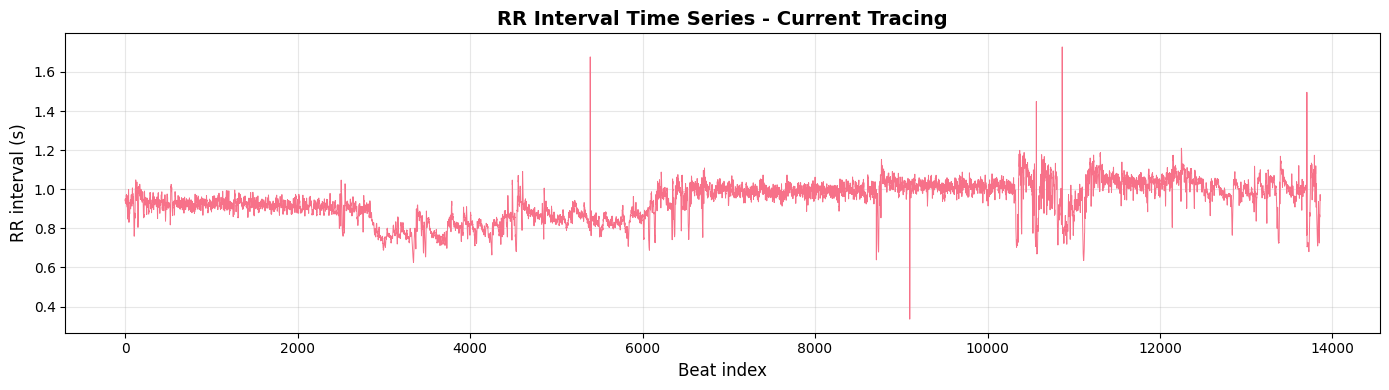

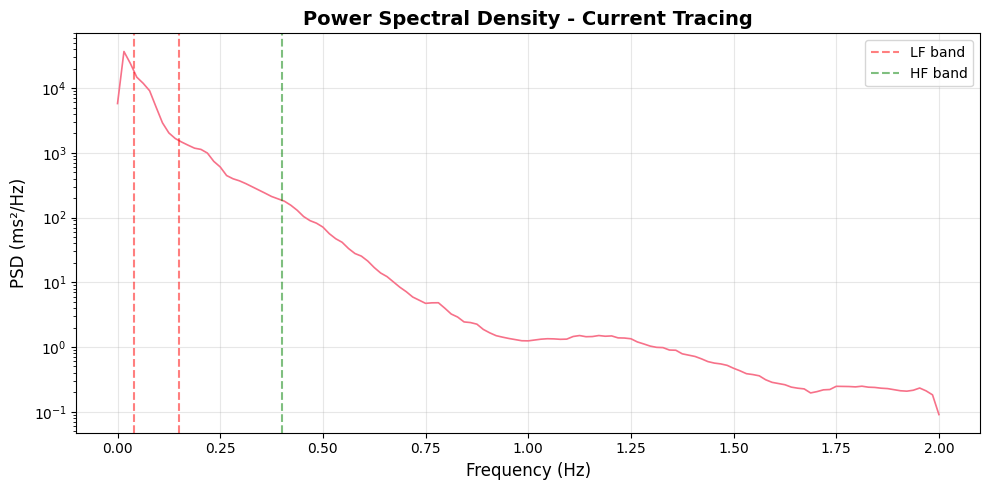

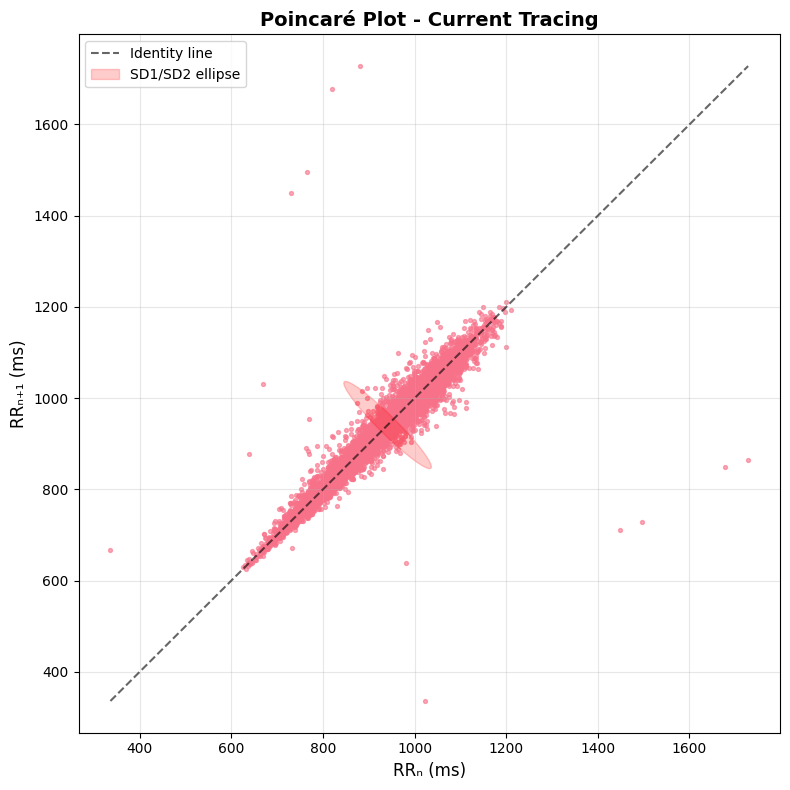

## Conclusions for Current HRV Tracing
- **Recording duration**: 217.36 min; **beats**: 13,859
- **Mean HR**: 64.5 bpm (if computed)

- **Time-domain**:
  - **SDNN**: 95.6 ms — above 5-min normative band (50±16 ms)
  - **RMSSD**: 27.6 ms — within 5-min normative band (42±15 ms)
  - **pNN50**: 1.9% (parasympathetic indicator)

- **Frequency-domain** (short-term references; high variability across cohorts):
  - **LF power**: 638.7 ms²; **HF power**: 197.1 ms²
  - **LF/HF**: 3.24 — within broad reference (~2.8±2.6)

- **Nonlinear**:
  - **Poincaré SD1/SD2**: 19.5/133.8 ms
  - **DFA α1**: 1.50 — above healthy range (0.75–1.25);
    **DFA α2**: 1.02 (long-term scaling)

- **Interpretation:**
  - Overall HRV (SDNN) above short-term norms; may reflect high vagal tone/fitness (confirm with context).
  - DFA α1 >1.25 suggests stronger persistence; interpret within protocol context.

- **Caveats:**
  - Short-term norms are defined for ~5-minute recordings; this tracing is 217.36 min.

- **References to normative values:** See the in-repo review `docs/Normative.md` (§2.1 short-term time-domain; §3.1 spectral; §5.2 DFA).

In [29]:
# 7. Scientific Plots & Conclusions for Current Tracing
from __future__ import annotations
from typing import Dict, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# 1) Resolve RR intervals from current tracing
rr_raw: np.ndarray
if 'df' in globals() and isinstance(globals().get('df'), pd.DataFrame):
    if 'rr_intervals_ms' in df.columns:
        rr_raw = df['rr_intervals_ms'].dropna().to_numpy()
    elif 'heart_rate [bpm]' in df.columns and 'rr_from_hr' in globals():
        rr_raw = rr_from_hr(df['heart_rate [bpm]'].dropna().to_numpy())
    elif 'rr_intervals' in globals():
        rr_raw = globals()['rr_intervals']
    else:
        rr_raw = np.array([], dtype=float)
elif 'rr_intervals' in globals():
    rr_raw = globals()['rr_intervals']
else:
    rr_raw = np.array([], dtype=float)

# Physiological filtering (300-2000 ms)
mask = (rr_raw >= 300.0) & (rr_raw <= 2000.0) if rr_raw.size else np.array([], dtype=bool)
rr: np.ndarray = rr_raw[mask] if rr_raw.size else rr_raw
if rr.size == 0:
    print("⚠️ No RR data available for plotting/conclusions.")
else:
    # 2) Plots (use existing helpers if available)
    if 'plot_rr_timeseries' in globals():
        plot_rr_timeseries(rr, "RR Interval Time Series - Current Tracing")
    else:
        # Minimal fallback plot
        plt.figure(figsize=(10, 3))
        plt.plot(np.arange(rr.size), rr / 1000.0, linewidth=0.7)
        plt.xlabel("Beat index")
        plt.ylabel("RR (s)")
        plt.title("RR Interval Time Series - Current Tracing")
        plt.tight_layout()
        plt.show()

    if rr.size >= 50:
        if 'plot_psd' in globals():
            plot_psd(rr, "Power Spectral Density - Current Tracing")
        else:
            print("ℹ️ PSD helper not available; skipping PSD plot.")
    else:
        print("ℹ️ <50 intervals: PSD skipped.")

    if rr.size >= 2:
        if 'plot_poincare' in globals():
            plot_poincare(rr, "Poincaré Plot - Current Tracing")
        else:
            print("ℹ️ Poincaré helper not available; skipping Poincaré plot.")
    else:
        print("ℹ️ <2 intervals: Poincaré skipped.")

    # 3) Compute metrics for conclusions
    has_compute = 'compute_comprehensive_hrv' in globals()
    if has_compute:
        use_hrva = bool(globals().get('HAS_HRVANALYSIS', False))
        current_metrics: Dict[str, float] = compute_comprehensive_hrv(rr, use_hrvanalysis=use_hrva)
    else:
        current_metrics = {}

    # 4) Build conclusions referencing docs/Normative.md
    def classify_relative(value: float, mu: float, sigma: float) -> str:
        if not np.isfinite(value):
            return "n/a"
        lo, hi = mu - sigma, mu + sigma
        if value < lo:
            return "below"
        if value > hi:
            return "above"
        return "within"

    # Normative anchors (short-term 5-min, unless stated). See docs/Normative.md §§2.1, 3.1, 5.2
    rmssd_mu, rmssd_sigma = 42.0, 15.0
    sdnn_short_mu, sdnn_short_sigma = 50.0, 16.0
    lfhf_mu, lfhf_sigma = 2.8, 2.6
    dfa_a1_lo, dfa_a1_hi = 0.75, 1.25

    duration_min: float = float(rr.sum() / (1000.0 * 60.0))
    sdnn = float(current_metrics.get('sdnn', np.nan))
    rmssd = float(current_metrics.get('rmssd', np.nan))
    pnn50 = float(current_metrics.get('pnn50', np.nan))
    lf_power = float(current_metrics.get('lf_power', np.nan))
    hf_power = float(current_metrics.get('hf_power', np.nan))
    lf_hf_ratio = float(current_metrics.get('lf_hf_ratio', np.nan))
    mean_hr = float(current_metrics.get('mean_hr', np.nan))
    sd1 = float(current_metrics.get('sd1', np.nan))
    sd2 = float(current_metrics.get('sd2', np.nan))
    dfa_alpha1 = float(current_metrics.get('dfa_alpha1', np.nan))
    dfa_alpha2 = float(current_metrics.get('dfa_alpha2', np.nan))

    rmssd_pos = classify_relative(rmssd, rmssd_mu, rmssd_sigma)
    sdnn_pos = classify_relative(sdnn, sdnn_short_mu, sdnn_short_sigma)
    lfhf_pos = classify_relative(lf_hf_ratio, lfhf_mu, lfhf_sigma)
    dfa_a1_pos = (
        "within" if np.isfinite(dfa_alpha1) and dfa_a1_lo <= dfa_alpha1 <= dfa_a1_hi
        else ("below" if np.isfinite(dfa_alpha1) and dfa_alpha1 < dfa_a1_lo else ("above" if np.isfinite(dfa_alpha1) and dfa_alpha1 > dfa_a1_hi else "n/a"))
    )

    cautions: list[str] = []
    if not (4.5 <= duration_min <= 6.0):
        cautions.append(f"Short-term norms are defined for ~5-minute recordings; this tracing is {duration_min:.2f} min.")
    if not np.isfinite(lf_power) or not np.isfinite(hf_power):
        cautions.append("Frequency-domain metrics unavailable or unstable (insufficient data or interpolation failure).")

    md_lines = [
        "## Conclusions for Current HRV Tracing",
        f"- **Recording duration**: {duration_min:.2f} min; **beats**: {rr.size:,}",
        f"- **Mean HR**: {mean_hr:.1f} bpm (if computed)",
        "",
        "- **Time-domain**:",
        f"  - **SDNN**: {sdnn:.1f} ms — {sdnn_pos} 5-min normative band (50±16 ms)",
        f"  - **RMSSD**: {rmssd:.1f} ms — {rmssd_pos} 5-min normative band (42±15 ms)",
        f"  - **pNN50**: {pnn50:.1f}% (parasympathetic indicator)",
        "",
        "- **Frequency-domain** (short-term references; high variability across cohorts):",
        f"  - **LF power**: {lf_power:.1f} ms²; **HF power**: {hf_power:.1f} ms²",
        f"  - **LF/HF**: {lf_hf_ratio:.2f} — {lfhf_pos} broad reference (~2.8±2.6)",
        "",
        "- **Nonlinear**:",
        f"  - **Poincaré SD1/SD2**: {sd1:.1f}/{sd2:.1f} ms",
        f"  - **DFA α1**: {dfa_alpha1:.2f} — {dfa_a1_pos} healthy range (0.75–1.25);",
        f"    **DFA α2**: {dfa_alpha2:.2f} (long-term scaling)",
        "",
    ]

    # Interpretation summary based on positions
    summary_points: list[str] = []
    if sdnn_pos == 'below':
        summary_points.append("Overall HRV (SDNN) appears lower than short-term norms; consider recovery, stress, or load factors.")
    elif sdnn_pos == 'above':
        summary_points.append("Overall HRV (SDNN) above short-term norms; may reflect high vagal tone/fitness (confirm with context).")

    if rmssd_pos == 'below':
        summary_points.append("Parasympathetic activity (RMSSD/SD1) appears reduced relative to short-term norms.")
    elif rmssd_pos == 'above':
        summary_points.append("Parasympathetic activity (RMSSD/SD1) appears elevated relative to short-term norms.")

    if np.isfinite(lf_hf_ratio):
        if lfhf_pos == 'above':
            summary_points.append("LF/HF above broad reference; do not over-interpret as 'sympathetic dominance' without context.")
        elif lfhf_pos == 'below':
            summary_points.append("LF/HF below broad reference; compatible with vagal predominance, but context matters (breathing rate).")

    if dfa_a1_pos == 'below':
        summary_points.append("DFA α1 <0.75 suggests reduced correlation structure; in exercise, this can indicate near/above aerobic threshold.")
    elif dfa_a1_pos == 'above':
        summary_points.append("DFA α1 >1.25 suggests stronger persistence; interpret within protocol context.")

    if not summary_points:
        summary_points.append("Metrics are broadly within commonly cited short-term references.")

    md_lines.append("- **Interpretation:**")
    for s in summary_points:
        md_lines.append(f"  - {s}")

    if cautions:
        md_lines.append("")
        md_lines.append("- **Caveats:**")
        for c in cautions:
            md_lines.append(f"  - {c}")

    md_lines.extend([
        "",
        "- **References to normative values:** See the in-repo review `docs/Normative.md` (§2.1 short-term time-domain; §3.1 spectral; §5.2 DFA).",
    ])

    display(Markdown("\n".join(md_lines)))



In [ ]:
# 8) Interactive plotting setup (Plotly + plotly-resampler)
# Note: This cell optionally installs pinned packages for interactive visualization.
# Justified exception to "no import-time side effects": environment preparation for the notebook runtime.

%pip install --quiet "plotly>=5.24,<6"

import importlib
import warnings
warnings.filterwarnings("ignore")

try:
    import plotly.graph_objects as go
    import plotly.express as px
except Exception as e:  # pragma: no cover
    raise RuntimeError("Plotly failed to import; ensure installation succeeded.") from e

# Try to import plotly-resampler; provide guidance if unavailable
try:
    from plotly_resampler import FigureResampler
    HAS_RESAMPLER: bool = True
except Exception:
    HAS_RESAMPLER = False
    print("ℹ️ plotly-resampler not available; using standard Plotly.")
    print("   To enable large-timeseries downsampling, try:")
    print("   %pip install -q plotly-resampler==0.11.0  # for Python 3.11/3.12 where available")

PLOTLY_TEMPLATE: str = "plotly_white"



In [ ]:
# 9) Multi-dataset configuration and loader
from __future__ import annotations
from dataclasses import dataclass
from typing import Optional, Dict, List, Literal, Tuple

@dataclass(slots=True)
class DatasetConfig:
    """Configuration for a single HRV dataset.

    Attributes:
        name: Unique identifier for the dataset.
        path: File path to the dataset. Supports .txt (RR list), .csv, .parquet.
        kind: One of {'txt_rr', 'csv', 'parquet'}.
        time_col: Name of timestamp column (optional). If absent, timestamps are constructed
                  from cumulative RR intervals when available.
        rr_col: Name of RR interval column in milliseconds (optional).
        hr_col: Name of heart rate column in bpm (optional). Used if rr_col absent.
    """
    name: str
    path: Optional[str]
    kind: Literal['txt_rr', 'csv', 'parquet']
    time_col: Optional[str] = None
    rr_col: Optional[str] = None
    hr_col: Optional[str] = None


def _parse_datetime_from_filename(path: str) -> Optional[pd.Timestamp]:
    """Attempt to parse 'YYYY-MM-DD HH-MM-SS' from filename; return None if not found."""
    import os
    from datetime import datetime
    filename = os.path.basename(path)
    base = filename.rsplit('.', 1)[0]
    for fmt in ("%Y-%m-%d %H-%M-%S", "%Y_%m_%d-%H_%M_%S", "%Y%m%d-%H%M%S"):
        try:
            return pd.Timestamp(datetime.strptime(base, fmt))
        except Exception:
            continue
    return None


def _ensure_rr_column(df_in: pd.DataFrame,
                      rr_col: Optional[str],
                      hr_col: Optional[str]) -> Tuple[pd.DataFrame, bool]:
    """Ensure DataFrame has 'rr_intervals_ms' with plausible values.

    Returns (df, has_rr) where df contains a fresh 'rr_intervals_ms' if derivable.
    """
    df = df_in.copy()
    has_rr = False

    if rr_col and rr_col in df.columns:
        rr = pd.to_numeric(df[rr_col], errors='coerce')
        rr = rr[(rr >= 300.0) & (rr <= 2000.0)]
        df = df.loc[rr.index].copy()
        df['rr_intervals_ms'] = rr.values
        has_rr = df['rr_intervals_ms'].notna().any()
    elif hr_col and hr_col in df.columns:
        rr = rr_from_hr(df[hr_col])
        df = df.loc[df[hr_col].dropna().index].copy()
        df['rr_intervals_ms'] = rr
        has_rr = df['rr_intervals_ms'].notna().any()
    return df, bool(has_rr)


def _ensure_timestamp(df_in: pd.DataFrame,
                      time_col: Optional[str]) -> pd.DataFrame:
    """Ensure DataFrame has a 'timestamp' column of dtype datetime64[ns]."""
    df = df_in.copy()
    if time_col and time_col in df.columns:
        df['timestamp'] = pd.to_datetime(df[time_col], errors='coerce', utc=False)
    elif 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', utc=False)
    else:
        # If we have RR intervals, construct timestamps from cumulative sum, anchored to filename time or index 0
        if 'rr_intervals_ms' in df.columns and df['rr_intervals_ms'].notna().any():
            start_ts = pd.Timestamp.now().normalize()
            if isinstance(df.attrs.get('recording_start'), pd.Timestamp):
                start_ts = df.attrs['recording_start']
            rr_sec = (pd.to_numeric(df['rr_intervals_ms'], errors='coerce') / 1000.0).fillna(0).to_numpy()
            t_cum = np.cumsum(rr_sec)
            df['timestamp'] = start_ts + pd.to_timedelta(t_cum, unit='s')
        else:
            # Fallback to monotonic index if nothing else
            df['timestamp'] = pd.to_datetime(pd.RangeIndex(len(df)), unit='s', origin='unix')
    return df


def load_dataset(config: DatasetConfig) -> pd.DataFrame:
    """Load a single dataset and unify columns.

    Returns a DataFrame with at least: ['timestamp', 'rr_intervals_ms', 'heart_rate [bpm]', 'source']
    Some columns may be NaN if not derivable.
    Error modes: returns empty DataFrame on failure.
    """
    if config.path is None:
        print(f"❌ Missing path for dataset '{config.name}'")
        return pd.DataFrame()

    try:
        if config.kind == 'txt_rr':
            rr = load_rr_intervals_from_txt(config.path)
            if rr.size == 0:
                return pd.DataFrame()
            # Derive HR, timestamps
            hr = 60000.0 / rr
            start_ts = _parse_datetime_from_filename(config.path) or pd.Timestamp.now().normalize()
            rr_cum_s = np.cumsum(rr) / 1000.0
            ts = start_ts + pd.to_timedelta(rr_cum_s, unit='s')
            out = pd.DataFrame({
                'timestamp': ts,
                'rr_intervals_ms': rr,
                'heart_rate [bpm]': hr,
                'beat_index': np.arange(rr.size, dtype=int),
                'source': config.name,
            })
            out.attrs['recording_start'] = start_ts
            return out

        if config.kind == 'csv':
            df = pd.read_csv(config.path)
        elif config.kind == 'parquet':
            df = pd.read_parquet(config.path)
        else:
            print(f"❌ Unsupported kind: {config.kind}")
            return pd.DataFrame()

        df, has_rr = _ensure_rr_column(df, rr_col=config.rr_col, hr_col=config.hr_col)
        # If HR was not present, compute from RR to maintain both
        if 'heart_rate [bpm]' not in df.columns and 'rr_intervals_ms' in df.columns:
            with np.errstate(divide='ignore', invalid='ignore'):
                df['heart_rate [bpm]'] = 60000.0 / df['rr_intervals_ms']
        df = _ensure_timestamp(df, time_col=config.time_col)
        df['source'] = config.name
        # Keep essential columns and drop rows with missing timestamp or rr
        keep = [c for c in ['timestamp', 'rr_intervals_ms', 'heart_rate [bpm]', 'beat_index', 'source'] if c in df.columns]
        df = df[keep].dropna(subset=['timestamp']).reset_index(drop=True)
        return df

    except Exception as e:
        print(f"❌ Failed to load '{config.name}': {e}")
        return pd.DataFrame()


def load_datasets(configs: List[DatasetConfig]) -> Dict[str, pd.DataFrame]:
    """Load multiple datasets according to the provided configurations.

    Returns mapping from dataset name to unified DataFrame.
    Skips datasets that fail to load, logging a warning.
    """
    datasets: Dict[str, pd.DataFrame] = {}
    for cfg in configs:
        df_i = load_dataset(cfg)
        if not df_i.empty:
            datasets[cfg.name] = df_i
            print(f"✅ Loaded '{cfg.name}': {len(df_i):,} rows")
        else:
            print(f"⚠️ Skipped '{cfg.name}' (empty or failed)")
    if not datasets:
        print("❌ No datasets loaded")
    return datasets



In [ ]:
# 10) Windowed HRV computation (sliding windows)
from __future__ import annotations
from typing import Iterable

def compute_windowed_hrv(
    df_in: pd.DataFrame,
    *,
    rr_col: str = 'rr_intervals_ms',
    timestamp_col: str = 'timestamp',
    window: str = '5min',
    step: str = '1min',
    min_rr_count: int = 60,
    max_windows: int = 500,
    use_hrvanalysis: bool = False,
) -> pd.DataFrame:
    """Compute HRV metrics over sliding windows.

    Args:
        df_in: Input DataFrame with at least rr_col and timestamp_col.
        rr_col: Column name of RR intervals in milliseconds.
        timestamp_col: Timestamp column used to segment windows.
        window: Window length (e.g., '5min').
        step: Step length between windows (e.g., '1min').
        min_rr_count: Minimum RR intervals required to compute metrics per window.
        max_windows: Upper bound on number of windows to compute to prevent runaway processing.
        use_hrvanalysis: Whether to leverage hrvanalysis if available.

    Returns:
        DataFrame with one row per window and HRV metrics, including 'start', 'end', 'source'.
    """
    if df_in.empty:
        return pd.DataFrame()

    df = df_in[[c for c in [timestamp_col, rr_col, 'source'] if c in df_in.columns]].dropna(subset=[timestamp_col])
    if rr_col not in df.columns:
        print("❌ RR column not found for windowed computation")
        return pd.DataFrame()

    # Sort by time and enforce plausible RR
    df = df.sort_values(timestamp_col).copy()
    rr_vals = pd.to_numeric(df[rr_col], errors='coerce')
    mask = (rr_vals >= 300.0) & (rr_vals <= 2000.0)
    df = df.loc[mask].copy()

    if df.empty:
        return pd.DataFrame()

    t0 = pd.to_datetime(df[timestamp_col].iloc[0])
    tN = pd.to_datetime(df[timestamp_col].iloc[-1])

    win_delta = pd.to_timedelta(window)
    step_delta = pd.to_timedelta(step)
    if not (pd.notna(win_delta) and pd.notna(step_delta)):
        raise ValueError("Invalid window/step specification")

    starts: List[pd.Timestamp] = []
    s = t0
    count = 0
    while s + win_delta <= tN and count < max_windows:
        starts.append(s)
        s = s + step_delta
        count += 1

    results: List[Dict[str, float]] = []
    if not starts:
        return pd.DataFrame()

    for s in starts:
        e = s + win_delta
        w = df[(df[timestamp_col] >= s) & (df[timestamp_col] < e)]
        if len(w) < min_rr_count:
            continue
        rr = w[rr_col].to_numpy()
        metrics = compute_comprehensive_hrv(rr, use_hrvanalysis=use_hrvanalysis)
        metrics['start'] = s
        metrics['end'] = e
        if 'source' in df.columns:
            # all rows in w share same source; safe to take first
            metrics['source'] = w['source'].iloc[0]
        results.append(metrics)

    if not results:
        return pd.DataFrame()

    return pd.DataFrame(results)



In [ ]:
# 11) Modern interactive plots for multi-dataset HRV/time series
from __future__ import annotations
from typing import Mapping

PLOT_BAND_COLORS = {
    'VLF': 'rgba(200,200,200,0.2)',
    'LF': 'rgba(255,99,132,0.15)',
    'HF': 'rgba(99,201,255,0.15)',
}


def _compute_psd_curve(rr: np.ndarray, sampling_rate: float = 4.0) -> Tuple[np.ndarray, np.ndarray]:
    """Return (freqs, psd) for a given RR sequence using Welch PSD on interpolated series."""
    if rr.size < 50:
        return np.array([]), np.array([])
    rr_s = rr / 1000.0
    r_times = np.concatenate([[0.0], np.cumsum(rr_s)])
    t_mid = (r_times[:-1] + r_times[1:]) / 2.0
    t_reg = np.arange(0.0, float(r_times[-1]), 1.0 / sampling_rate)
    if t_reg.size < 10:
        return np.array([]), np.array([])
    kind = 'cubic' if rr.size >= 4 else 'linear'
    f = interp1d(t_mid, rr, kind=kind, bounds_error=False, fill_value='extrapolate')
    rr_interp = f(t_reg)
    rr_det = signal.detrend(rr_interp)
    freqs, psd = signal.welch(rr_det, fs=sampling_rate, nperseg=min(len(rr_det)//4, 256), window='hann')
    return freqs, psd


def plot_multi_hr_timeseries(datasets: Mapping[str, pd.DataFrame], *,
                              timestamp_col: str = 'timestamp',
                              hr_col: str = 'heart_rate [bpm]') -> None:
    """Interactive HR timeseries overlay across datasets."""
    if not datasets:
        print("No datasets to plot")
        return
    if HAS_RESAMPLER:
        fig = FigureResampler(go.Figure())
        for name, df in datasets.items():
            if hr_col in df.columns and timestamp_col in df.columns:
                fig.add_trace(go.Scattergl(name=name, mode='lines'),
                              hf_x=df[timestamp_col], hf_y=df[hr_col])
    else:
        fig = go.Figure()
        for name, df in datasets.items():
            if hr_col in df.columns and timestamp_col in df.columns:
                fig.add_trace(go.Scattergl(x=df[timestamp_col], y=df[hr_col], name=name, mode='lines'))
    fig.update_layout(title='Heart Rate over Time (by dataset)',
                      xaxis_title='Time', yaxis_title='HR (bpm)',
                      template=PLOTLY_TEMPLATE, legend_title='Dataset',
                      xaxis=dict(rangeslider=dict(visible=True)))
    fig.show()


def plot_multi_rr_timeseries(datasets: Mapping[str, pd.DataFrame], *,
                              timestamp_col: str = 'timestamp',
                              rr_col: str = 'rr_intervals_ms') -> None:
    """Interactive RR timeseries overlay across datasets."""
    if not datasets:
        print("No datasets to plot")
        return
    if HAS_RESAMPLER:
        fig = FigureResampler(go.Figure())
        for name, df in datasets.items():
            if rr_col in df.columns and timestamp_col in df.columns:
                fig.add_trace(go.Scattergl(name=name, mode='lines'),
                              hf_x=df[timestamp_col], hf_y=df[rr_col])
    else:
        fig = go.Figure()
        for name, df in datasets.items():
            if rr_col in df.columns and timestamp_col in df.columns:
                fig.add_trace(go.Scattergl(x=df[timestamp_col], y=df[rr_col], name=name, mode='lines'))
    fig.update_layout(title='RR Interval over Time (by dataset)',
                      xaxis_title='Time', yaxis_title='RR (ms)',
                      template=PLOTLY_TEMPLATE, legend_title='Dataset',
                      xaxis=dict(rangeslider=dict(visible=True)))
    fig.show()


def plot_multi_psd_overlay(datasets: Mapping[str, pd.DataFrame], *,
                            rr_col: str = 'rr_intervals_ms',
                            sampling_rate: float = 4.0) -> None:
    """Overlay PSD curves across datasets with HRV band shading."""
    if not datasets:
        print("No datasets to plot")
        return
    fig = go.Figure()
    # Band shading
    bands = {'VLF': (0.0033, 0.04), 'LF': (0.04, 0.15), 'HF': (0.15, 0.4)}
    for band, (f0, f1) in bands.items():
        fig.add_vrect(x0=f0, x1=f1, fillcolor=PLOT_BAND_COLORS[band], line_width=0, layer='below', annotation_text=band, annotation_position='top left')
    # Curves
    for name, df in datasets.items():
        if rr_col not in df.columns:
            continue
        rr = pd.to_numeric(df[rr_col], errors='coerce').dropna().to_numpy()
        freqs, psd = _compute_psd_curve(rr, sampling_rate=sampling_rate)
        if freqs.size == 0:
            continue
        fig.add_trace(go.Scatter(x=freqs, y=psd, name=name, mode='lines'))
    fig.update_layout(title='PSD Overlay (Welch) with HRV Bands', xaxis_title='Frequency (Hz)', yaxis_title='PSD (ms²/Hz)', template=PLOTLY_TEMPLATE, legend_title='Dataset', yaxis_type='log')
    fig.show()


def plot_poincare_interactive(datasets: Mapping[str, pd.DataFrame], *,
                              rr_col: str = 'rr_intervals_ms',
                              max_points_per_ds: int = 5000) -> None:
    """Interactive Poincaré plot per dataset with downsampling for performance."""
    if not datasets:
        print("No datasets to plot")
        return
    fig = go.Figure()
    for name, df in datasets.items():
        if rr_col not in df.columns:
            continue
        rr = pd.to_numeric(df[rr_col], errors='coerce').dropna().to_numpy()
        rr = rr[(rr >= 300.0) & (rr <= 2000.0)]
        if rr.size < 2:
            continue
        rr1 = rr[:-1]
        rr2 = rr[1:]
        n = rr1.size
        if n > max_points_per_ds:
            idx = np.linspace(0, n - 1, max_points_per_ds).astype(int)
            rr1 = rr1[idx]
            rr2 = rr2[idx]
        fig.add_trace(go.Scattergl(x=rr1, y=rr2, mode='markers', name=name, opacity=0.5))
    fig.update_layout(title='Poincaré Plot (RRₙ vs RRₙ₊₁)', xaxis_title='RRₙ (ms)', yaxis_title='RRₙ₊₁ (ms)', template=PLOTLY_TEMPLATE, legend_title='Dataset')
    fig.show()


def plot_window_trend(windowed: pd.DataFrame, metric: str) -> None:
    """Interactive trend of a metric over time across datasets (windowed results)."""
    if windowed.empty or metric not in windowed.columns:
        print("No data/metric to plot")
        return
    dfp = windowed[['start', 'source', metric]].dropna().copy()
    dfp = dfp.rename(columns={'start': 'time'})
    fig = px.line(dfp, x='time', y=metric, color='source', template=PLOTLY_TEMPLATE, title=f'{metric} over time (windowed)')
    fig.update_layout(legend_title='Dataset', xaxis=dict(rangeslider=dict(visible=True)))
    fig.show()


def plot_rr_spectrogram(df: pd.DataFrame, *,
                         timestamp_col: str = 'timestamp',
                         rr_col: str = 'rr_intervals_ms',
                         sampling_rate: float = 4.0,
                         name: Optional[str] = None) -> None:
    """Time-frequency representation (spectrogram) of interpolated RR intervals."""
    if rr_col not in df.columns or timestamp_col not in df.columns:
        print("Missing columns for spectrogram")
        return
    rr = pd.to_numeric(df[rr_col], errors='coerce').dropna().to_numpy()
    if rr.size < 200:
        print("Insufficient RR for spectrogram")
        return
    # Interpolate to regular grid
    rr_s = rr / 1000.0
    r_times = np.concatenate([[0.0], np.cumsum(rr_s)])
    t_mid = (r_times[:-1] + r_times[1:]) / 2.0
    t_reg = np.arange(0.0, float(r_times[-1]), 1.0 / sampling_rate)
    f = interp1d(t_mid, rr, kind='linear', bounds_error=False, fill_value='extrapolate')
    rr_interp = f(t_reg)
    rr_det = signal.detrend(rr_interp)
    fxx, txx, Sxx = signal.spectrogram(rr_det, fs=sampling_rate, window='hann', nperseg=min(256, len(rr_det)//4), noverlap=None, detrend=False, scaling='density', mode='psd')
    title = f"RR Spectrogram{' - ' + name if name else ''}"
    fig = px.imshow(Sxx, origin='lower', x=txx, y=fxx, aspect='auto', template=PLOTLY_TEMPLATE, color_continuous_scale='Viridis', labels={'x': 'Time (s)', 'y': 'Frequency (Hz)', 'color': 'PSD'})
    fig.update_layout(title=title, yaxis_range=[0, 0.5])
    fig.show()



In [ ]:
# 12) Load multiple datasets, compute metrics, and render interactive plots
from __future__ import annotations

# Define your datasets here. Add more DatasetConfig entries as needed.
# Example templates:
# DatasetConfig(name='DatasetA', path=r'C:\path\to\fileA.csv', kind='csv', time_col='timestamp', rr_col='rr_ms')
# DatasetConfig(name='DatasetB', path=r'C:\path\to\fileB.parquet', kind='parquet', time_col='time', hr_col='hr_bpm')

multi_configs: List[DatasetConfig] = []

# Include the current RR text recording as a dataset (if the path exists)
try:
    _default_rr_path = rr_file_path  # from earlier cell
    multi_configs.append(DatasetConfig(name='PolarRecording', path=_default_rr_path, kind='txt_rr'))
except Exception:
    pass

# TODO: Add your other datasets here by appending DatasetConfig(...)

multi_datasets: Dict[str, pd.DataFrame] = load_datasets(multi_configs) if multi_configs else {}

# If nothing loaded and a global df exists, fall back to it as a single dataset
if not multi_datasets and 'df' in globals() and isinstance(df, pd.DataFrame) and not df.empty:
    src_name = df.get('source', pd.Series(['Current'] * len(df))).iloc[0] if 'source' in df.columns else 'Current'
    df_fallback = df.copy()
    if 'source' not in df_fallback.columns:
        df_fallback['source'] = src_name
    multi_datasets = {src_name: df_fallback}

print(f"Datasets available: {list(multi_datasets.keys())}")

# Compute windowed metrics for each dataset
windowed_all: List[pd.DataFrame] = []
for name, dfi in multi_datasets.items():
    wdf = compute_windowed_hrv(dfi, window='5min', step='1min', use_hrvanalysis=HAS_HRVANALYSIS)
    if not wdf.empty:
        windowed_all.append(wdf)
windowed_all_df = pd.concat(windowed_all, ignore_index=True) if windowed_all else pd.DataFrame()

# Compute overall HRV for each dataset (full recording)
multi_results: List[Dict[str, float]] = []
for name, dfi in multi_datasets.items():
    if 'rr_intervals_ms' in dfi.columns:
        rr = pd.to_numeric(dfi['rr_intervals_ms'], errors='coerce').dropna().to_numpy()
        rr = rr[(rr >= 300.0) & (rr <= 2000.0)]
        if rr.size >= 10:
            m = compute_comprehensive_hrv(rr, use_hrvanalysis=HAS_HRVANALYSIS)
            m['source'] = name
            multi_results.append(m)

multi_results_df = pd.DataFrame(multi_results) if multi_results else pd.DataFrame()

# Render interactive plots (skip if no data)
if multi_datasets:
    # Timeseries
    try:
        plot_multi_hr_timeseries(multi_datasets)
    except Exception as e:
        print(f"Plot HR failed: {e}")
    try:
        plot_multi_rr_timeseries(multi_datasets)
    except Exception as e:
        print(f"Plot RR failed: {e}")

    # PSD overlay
    try:
        plot_multi_psd_overlay(multi_datasets)
    except Exception as e:
        print(f"Plot PSD failed: {e}")

    # Poincaré
    try:
        plot_poincare_interactive(multi_datasets)
    except Exception as e:
        print(f"Plot Poincaré failed: {e}")

# Windowed trends for key metrics
if not windowed_all_df.empty:
    for metric in ['rmssd', 'hf_nu', 'lf_hf_ratio']:
        if metric in windowed_all_df.columns:
            try:
                plot_window_trend(windowed_all_df, metric)
            except Exception as e:
                print(f"Plot trend '{metric}' failed: {e}")

# Show overall results table
if not multi_results_df.empty:
    print("\nOverall HRV (full-recording) per dataset:")
    display(multi_results_df[['source'] + [c for c in multi_results_df.columns if c != 'source']])



In [ ]:
# 13) Interpretation across multiple datasets
from __future__ import annotations
from IPython.display import Markdown, display

def _pos_str(value: float, ref_mu: float, ref_sigma: float) -> str:
    if not np.isfinite(value):
        return "n/a"
    lo, hi = ref_mu - ref_sigma, ref_mu + ref_sigma
    if value < lo:
        return "below"
    if value > hi:
        return "above"
    return "within"

if 'multi_results_df' in globals() and isinstance(multi_results_df, pd.DataFrame) and not multi_results_df.empty:
    # Norm anchors (short-term, commonly cited)
    rmssd_mu, rmssd_sigma = 42.0, 15.0
    sdnn_short_mu, sdnn_short_sigma = 50.0, 16.0
    lfhf_mu, lfhf_sigma = 2.8, 2.6

    lines: List[str] = [
        "## Multi-Dataset HRV Interpretation",
        "",
        f"Datasets analyzed: {', '.join(multi_results_df['source'].astype(str).tolist())}",
        "",
        "- **Overall (full recording)**:",
    ]

    for _, row in multi_results_df.iterrows():
        src = str(row.get('source', 'N/A'))
        sdnn = float(row.get('sdnn', np.nan))
        rmssd = float(row.get('rmssd', np.nan))
        lfhf = float(row.get('lf_hf_ratio', np.nan))
        hf_nu = float(row.get('hf_nu', np.nan))
        sd1 = float(row.get('sd1', np.nan))
        sd2 = float(row.get('sd2', np.nan))
        dfa_a1 = float(row.get('dfa_alpha1', np.nan))

        lines.append(
            f"  - {src}: SDNN {sdnn:.1f} ms ({_pos_str(sdnn, sdnn_short_mu, sdnn_short_sigma)} 5-min ref), "
            f"RMSSD {rmssd:.1f} ms ({_pos_str(rmssd, rmssd_mu, rmssd_sigma)}), "
            f"LF/HF {lfhf:.2f} ({_pos_str(lfhf, lfhf_mu, lfhf_sigma)}), HF_nu {hf_nu:.1f}%, SD1/SD2 {sd1:.1f}/{sd2:.1f}, DFA α1 {dfa_a1:.2f}"
        )

    # Windowed summaries if available
    if 'windowed_all_df' in globals() and isinstance(windowed_all_df, pd.DataFrame) and not windowed_all_df.empty:
        lines.extend(["", "- **Windowed trends (5-min, 1-min step)**:"])
        for metric in ['rmssd', 'hf_nu', 'lf_hf_ratio']:
            if metric in windowed_all_df.columns:
                agg = windowed_all_df.groupby('source')[metric].median().sort_values(ascending=False)
                top = agg.index[0]
                lines.append(f"  - Median {metric}: highest in {top} (top-to-bottom: {', '.join([f'{k}={v:.1f}' for k, v in agg.to_dict().items()])})")

    # Narrative interpretation
    narrative: List[str] = []
    if 'rmssd' in multi_results_df.columns:
        best_rmssd_src = multi_results_df.sort_values('rmssd', ascending=False)['source'].iloc[0]
        narrative.append(f"Higher short-term vagal activity is suggested in {best_rmssd_src} (by RMSSD/SD1).")
    if 'lf_hf_ratio' in multi_results_df.columns:
        high_lfhf_src = multi_results_df.sort_values('lf_hf_ratio', ascending=False)['source'].iloc[0]
        narrative.append(f"Relative sympathetic predominance (higher LF/HF) appears in {high_lfhf_src}; interpret with breathing/context.")
    if 'dfa_alpha1' in multi_results_df.columns and multi_results_df['dfa_alpha1'].notna().any():
        near_one = (multi_results_df['dfa_alpha1'] - 1.0).abs().sort_values().index[0]
        near_one_src = multi_results_df.loc[near_one, 'source']
        narrative.append(f"Fractal short-term scaling (DFA α1) closest to 1.0 in {near_one_src}, suggestive of healthy correlation structure.")
    if not narrative:
        narrative.append("Across datasets, metrics are broadly within commonly cited short-term references.")

    lines.extend(["", "- **Interpretation:**"])
    lines.extend([f"  - {n}" for n in narrative])

    lines.extend([
        "",
        "- **Caveats:**",
        "  - Short-term references apply to ~5-minute segments; ensure protocol comparability.",
        "  - Spectral metrics depend on breathing rate and stationarity; uneven sampling and artifacts can bias estimates.",
        "  - See `docs/Normative.md` for references and ranges.",
    ])

    display(Markdown("\n".join(lines)))
else:
    print("No multi-dataset results available for interpretation.")

